# 02 — Pipeline de Imputación

## 0. Setup

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import os

from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

IMAGES_DIR = '../figures'
os.makedirs(IMAGES_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(IMAGES_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches='tight')

print('Setup passed  |  random_state =', RANDOM_STATE)

Setup passed  |  random_state = 42


## 1. Carga y normalización

In [39]:
RAW_PATH = '../dataset.csv'
ENCODED_MISSING = {'No information','Does not apply','Does not apply ','does not apply','N/A',''}

def load_and_normalize(path):
    df = pd.read_csv(path)
    df = df[df['school'] != 'High school'].copy().reset_index(drop=True)
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].apply(
            lambda x: np.nan if (isinstance(x, str) and x.strip() in ENCODED_MISSING) else x)
    for col in ['admission.test', 'general.math.eval']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['regime'] = df['educational.model'].map({0: 'PreTec21', 1: 'Tec21'})
    return df

df = load_and_normalize(RAW_PATH)
print(f'Dataset: {df.shape}  |  PreTec21: {(df.regime=="PreTec21").sum():,}  |  Tec21: {(df.regime=="Tec21").sum():,}')
print(f'Tasa de deserción: {(df.retention==0).mean()*100:.1f}%')

Dataset: (77517, 51)  |  PreTec21: 53,010  |  Tec21: 24,507
Tasa de deserción: 8.8%


## 2. División train / test

In [40]:
train = df[df['regime'] == 'PreTec21'].copy()  
test  = df[df['regime'] == 'Tec21'].copy()      
print(f'Train (PreTec21): {len(train):,}  |  Test (Tec21): {len(test):,}')

Train (PreTec21): 53,010  |  Test (Tec21): 24,507


## 3. Indicadores binarios (antes de imputar)

In [41]:
def create_indicators(df):
    df = df.copy()
    df['took_admission_test']    = df['admission.test'].notna().astype(int)
    df['first_gen_present']      = df['first.generation'].notna().astype(int)
    df['parents_edu_present']    = df['max.degree.parents'].notna().astype(int)
    df['has_life_activities']    = df['total.life.activities'].notna().astype(int)
    df['has_socioeconomic_data'] = df['socioeconomic.level'].notna().astype(int)
    df['has_social_lag_data']    = df['social.lag'].notna().astype(int)
    df['has_zone_data']          = df['zone.type'].notna().astype(int)
    return df

train = create_indicators(train)
test  = create_indicators(test)

print('Indicadores creados:')
for ind in ['took_admission_test','first_gen_present','has_life_activities','has_socioeconomic_data']:
    print(f'  {ind}: train={train[ind].mean()*100:.1f}% | test={test[ind].mean()*100:.1f}%')

Indicadores creados:
  took_admission_test: train=65.8% | test=70.9%
  first_gen_present: train=29.6% | test=99.8%
  has_life_activities: train=21.3% | test=99.6%
  has_socioeconomic_data: train=0.0% | test=45.2%


## 4. Moda por grupo (parents.exatec, physical.education, total.life.activities)

In [42]:
class GroupModeImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_col, group_cols):
        self.target_col = target_col
        self.group_cols = group_cols

    def fit(self, X, y=None):
        self.group_modes_ = (
            X.groupby(self.group_cols)[self.target_col]
             .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
             .to_dict()
        )
        m = X[self.target_col].mode()
        self.global_mode_ = m.iloc[0] if not m.empty else np.nan
        return self

    def transform(self, X):
        X = X.copy()
        mask = X[self.target_col].isnull()
        if mask.sum() == 0:
            return X
        def fill_row(row):
            if not pd.isnull(row[self.target_col]):
                return row[self.target_col]
            key = tuple(row[g] for g in self.group_cols)
            return self.group_modes_.get(key, self.global_mode_)
        X.loc[mask, self.target_col] = X[mask].apply(fill_row, axis=1)
        return X

group_imputers = {}
for col in ['parents.exatec', 'physical.education', 'total.life.activities']:
    imp = GroupModeImputer(col, ['school', 'regime'])
    imp.fit(train)
    train = imp.transform(train)
    test  = imp.transform(test)
    group_imputers[col] = imp
    print(f'{col}: NaN -> train={train[col].isnull().sum()} | test={test[col].isnull().sum()}')

parents.exatec: NaN -> train=0 | test=0
physical.education: NaN -> train=0 | test=0
total.life.activities: NaN -> train=0 | test=0


## 5. KNN Imputer - numéricos 
`general.math.eval` tiene faltantes exclusivamente en PreTec21 (14.8% vs 0% en Tec21).   
El KNN de `general.math.eval` hace `fit` solo en PreTec21, usando únicamente vecinos del mismo régimen.

In [43]:
KNN_FEATS = ['PNA', 'english.evaluation', 'online.test', 'scholarship.perc', 'loan.perc']

# admission.test: fit en train, transform en ambos
# (El faltante de admission.test es estructural y existe en ambos regímenes)
knn_adm = KNNImputer(n_neighbors=5, weights='distance')
adm_cols = KNN_FEATS + ['admission.test']
train['admission.test'] = pd.DataFrame(
    knn_adm.fit_transform(train[adm_cols]), columns=adm_cols, index=train.index)['admission.test']
test['admission.test'] = pd.DataFrame(
    knn_adm.transform(test[adm_cols]), columns=adm_cols, index=test.index)['admission.test']

knn_gme = KNNImputer(n_neighbors=5, weights='distance')
gme_cols = KNN_FEATS + ['general.math.eval']
knn_gme.fit(train[gme_cols])   # fit en PreTec21 únicamente
train['general.math.eval'] = pd.DataFrame(
    knn_gme.transform(train[gme_cols]), columns=gme_cols, index=train.index)['general.math.eval']
test['general.math.eval'] = pd.DataFrame(
    knn_gme.transform(test[gme_cols]), columns=gme_cols, index=test.index)['general.math.eval']

orig_gme  = df[df['regime']=='PreTec21']['general.math.eval'].dropna()
was_nan   = df[df['regime']=='PreTec21']['general.math.eval'].isna()
imp_gme   = train.loc[was_nan, 'general.math.eval']
ks, p = stats.ks_2samp(orig_gme, imp_gme)
print(f'general.math.eval -> originales: mean={orig_gme.mean():.2f} std={orig_gme.std():.2f}')
print(f'                  -> imputados:  mean={imp_gme.mean():.2f} std={imp_gme.std():.2f}')
print(f'                  -> KS test: D={ks:.3f}, p={p:.4f}')
print(f'admission.test NaN -> train={train["admission.test"].isnull().sum()} | test={test["admission.test"].isnull().sum()}')

general.math.eval -> originales: mean=73.56 std=19.38
                  -> imputados:  mean=66.25 std=16.19
                  -> KS test: D=0.310, p=0.0000
admission.test NaN -> train=0 | test=0


## 6. MICE — admission.rubric

`RandomForestRegressor` captura la distribución asimétrica de la rubrica (cola hacia valores altos, p75=40, p95=50) sin asumir linealidad.  
Se aplica `clip(0, 50)` para garantizar que ningún valor imputado salga del rango válido.

In [44]:
MICE_FEATS = [
    'PNA', 'english.evaluation', 'online.test', 'scholarship.perc', 'loan.perc',
    'general.math.eval', 'admission.test', 'admission.rubric'
]

mice = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=50, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1
    ),
    max_iter=5,
    random_state=RANDOM_STATE,
    verbose=0
)

tr_m = pd.DataFrame(mice.fit_transform(train[MICE_FEATS]), columns=MICE_FEATS, index=train.index)
te_m = pd.DataFrame(mice.transform(test[MICE_FEATS]), columns=MICE_FEATS, index=test.index)

# Clamp al rango válido
train['admission.rubric'] = tr_m['admission.rubric'].clip(0, 50)
test['admission.rubric']  = te_m['admission.rubric'].clip(0, 50)

orig_rub = df['admission.rubric'].dropna()
was_nan_r = df[df['regime']=='PreTec21']['admission.rubric'].isna()
imp_rub   = train.loc[was_nan_r, 'admission.rubric']
print(f'admission.rubric -> originales: mean={orig_rub.mean():.2f}  std={orig_rub.std():.2f}')
print(f'                 -> imputados:  mean={imp_rub.mean():.2f}  std={imp_rub.std():.2f}  (v1 era 2.49)')
print(f'                 -> fuera de [0,50]: {((train["admission.rubric"]<0)|(train["admission.rubric"]>50)).sum()}')

admission.rubric -> originales: mean=34.92  std=9.60
                 -> imputados:  mean=33.47  std=2.71  (v1 era 2.49)
                 -> fuera de [0,50]: 0


## 7. RF Classifier- first.generation y max.degree.parents 

Las variables disponibles (PNA, beca, escuela) tienen distribuciones casi idénticas entre los grupos `Yes`, `No` y `NaN` en `first.generation`. El RF no puede discriminar bien porque la información discriminante (ingreso familiar, origen rural/urbano, generación en universidad) no está en el dataset. 

In [45]:
class RFCategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_col, feature_cols, random_state=42):
        self.target_col = target_col
        self.feature_cols = feature_cols
        self.random_state = random_state
        self.model_ = None
        self.le_ = LabelEncoder()
        self.feature_encoders_ = {}

    def _encode(self, X, fit=False):
        Xe = X[self.feature_cols].copy()
        for col in Xe.select_dtypes(include='object').columns:
            if fit:
                le = LabelEncoder()
                le.fit(Xe[col].fillna('MISSING').astype(str).unique().tolist() + ['UNKNOWN'])
                self.feature_encoders_[col] = le
            le = self.feature_encoders_.get(col)
            if le:
                Xe[col] = le.transform(
                    Xe[col].fillna('MISSING').astype(str).apply(
                        lambda v: v if v in le.classes_ else 'UNKNOWN'))
            else:
                Xe[col] = 0
        return Xe.fillna(-1).values

    def fit(self, X, y=None):
        mask = X[self.target_col].notna()
        Xf = self._encode(X[mask], fit=True)
        yf = self.le_.fit_transform(X[mask][self.target_col].astype(str))
        self.model_ = RandomForestClassifier(
            n_estimators=200, max_depth=10, random_state=self.random_state,
            n_jobs=-1, class_weight='balanced', min_samples_leaf=5
        )
        self.model_.fit(Xf, yf)
        preds_missing = self.model_.predict(self._encode(X[~mask], fit=False))
        dist = {self.le_.classes_[int(k)]: round(v, 3)
                for k, v in pd.Series(preds_missing).value_counts(normalize=True).items()}
        f1 = f1_score(yf, self.model_.predict(Xf), average='weighted')
        print(f'  [{self.target_col}] n_known={mask.sum():,}, f1_train={f1:.3f}, dist_imputados={dist}')
        return self

    def transform(self, X):
        X = X.copy()
        mask = X[self.target_col].isna()
        if mask.sum() == 0:
            return X
        X.loc[mask, self.target_col] = self.le_.inverse_transform(
            self.model_.predict(self._encode(X[mask], fit=False)))
        return X


RF_FEATS = [
    'school', 'regime', 'PNA', 'scholarship.perc', 'loan.perc',
    'english.evaluation', 'general.math.eval',
    'has_life_activities', 'took_admission_test'
]

rf_fg = RFCategoricalImputer('first.generation', RF_FEATS + ['max.degree.parents'], RANDOM_STATE)
rf_fg.fit(train)
train = rf_fg.transform(train)
test  = rf_fg.transform(test)

rf_pe = RFCategoricalImputer('max.degree.parents', RF_FEATS + ['first.generation'], RANDOM_STATE)
rf_pe.fit(train)
train = rf_pe.transform(train)
test  = rf_pe.transform(test)


  [first.generation] n_known=15,693, f1_train=0.996, dist_imputados={'No': 0.99, 'Yes': 0.01}
  [max.degree.parents] n_known=17,810, f1_train=0.634, dist_imputados={'Undergraduate degree': 0.558, 'Master degree': 0.37, 'PhD': 0.071, 'No degree': 0.002}


## 8. Validación post-imputación

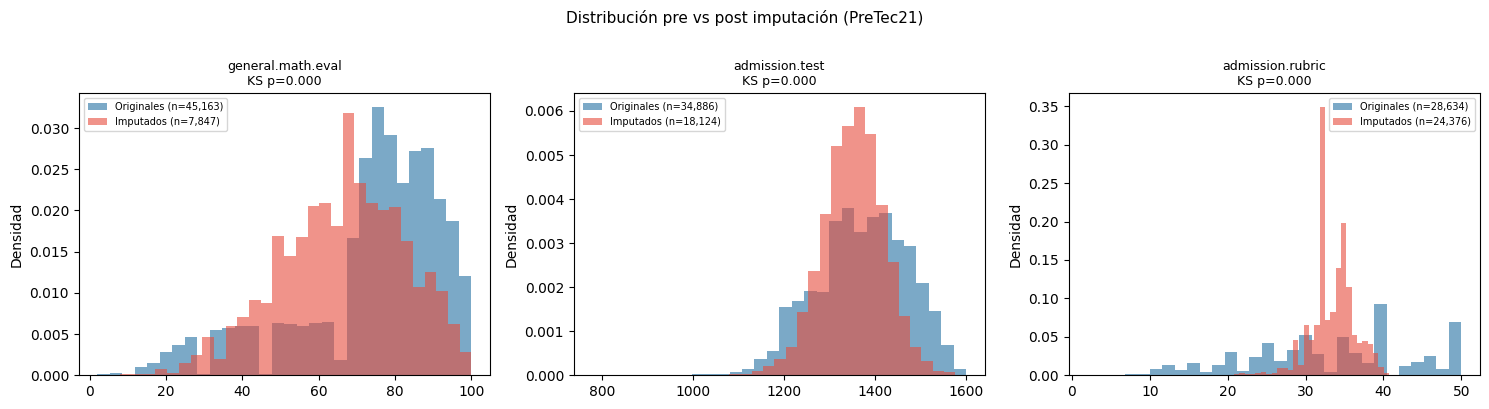

In [46]:
df_pre_orig = df[df['regime']=='PreTec21'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
NUM_IMPUTED = ['general.math.eval', 'admission.test', 'admission.rubric']

for ax, col in zip(axes, NUM_IMPUTED):
    original = df_pre_orig[col].dropna()
    imputed  = train[col][df_pre_orig[col].isna()]
    ax.hist(original, bins=30, alpha=0.6, color='#2471A3',
            label=f'Originales (n={len(original):,})', density=True)
    if len(imputed) > 0:
        ax.hist(imputed, bins=30, alpha=0.6, color='#E74C3C',
                label=f'Imputados (n={len(imputed):,})', density=True)
        ks, p = stats.ks_2samp(original, imputed)
        ax.set_title(f'{col}\nKS p={p:.3f}', fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel('Densidad')

plt.suptitle('Distribución pre vs post imputación (PreTec21)', fontsize=11, y=1.01)
plt.tight_layout()
save_fig('01_dist_prepost_numericas_v2.png')
plt.show()

## 9. Exportar dataset imputado

In [47]:
df_imputed = pd.concat([train, test]).sort_index().reset_index(drop=True)

print(f'Shape: {df_imputed.shape}')
print(f'Tasa deserción: {(df_imputed.retention==0).mean()*100:.2f}%')

print(f'Nuevas columnas indicadoras: {[c for c in df_imputed.columns if any(x in c for x in ["present","took","has_"])]}')

OUTPUT_PATH = '../../dataset_imputed.csv'
df_imputed.to_csv(OUTPUT_PATH, index=False)
print(f'\nExportado a {OUTPUT_PATH}')

Shape: (77517, 58)
Tasa deserción: 8.79%
Nuevas columnas indicadoras: ['took_admission_test', 'first_gen_present', 'parents_edu_present', 'has_life_activities', 'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data']

Exportado a ../../dataset_imputed.csv
